In [23]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
base_path = Path("/content/drive/MyDrive/Colab_Notebooks") # change to path folder with data


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

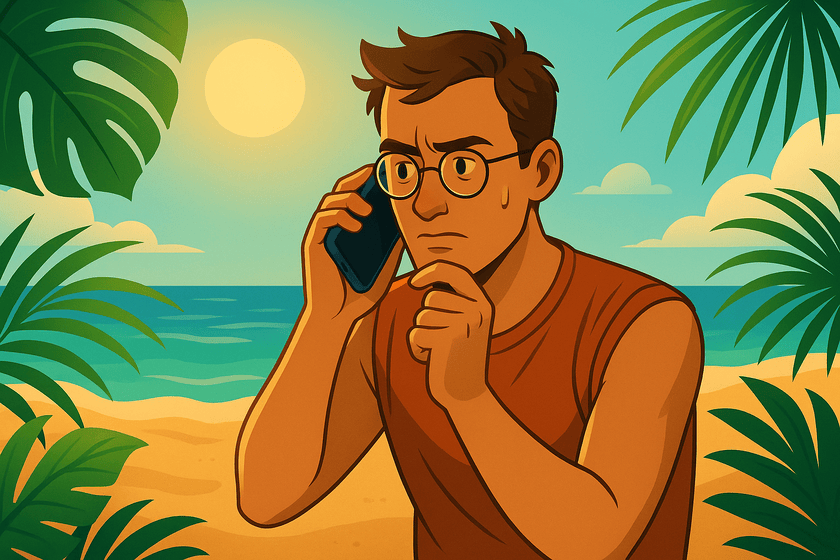

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


# Rozwiązanie zadania

## Function def

In [25]:
def get_percentage_missing(df, axis):
  """
    Zwraca procent brakujących wartości (NaN) w wierszach lub kolumnach DataFrame.

    df : pandas.DataFrame
        Tabela danych, dla której liczone są braki.

    axis : int
        Oś, względem której obliczane są braki:
        - 0 : procent braków w każdej kolumnie
        - 891 : procent braków w każdym wierszu
  """
  missing_rows = df.isna().sum(axis=axis)
  missing_rows_perc = np.round(missing_rows / df.shape[axis] * 100, 2)
  return missing_rows_perc[missing_rows_perc > 0]

def boxplot(df, column_name):
    """
    Displays a boxplot of the choosen column to show its distribution.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the categorical column to plot.
    Returns:
        None. Displays the bar chart.
    """
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column_name].dropna(), color='lightgreen') # as you can see, you can use sns and plt at the same time
    plt.title(f'Distribution of {column_name} (boxplot)')
    plt.xlabel(column_name)

    plt.show()

def boxplot_with_categorical(df, column_name, categorical_column_name):
    """
    Displays a boxplot of the chosen column to show its distribution.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the numerical column to plot.
        categorical_column_name (str): The name of the categorical column to group by.
    Returns:
        None. Displays the boxplot.
    """
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=categorical_column_name, y=column_name)
    plt.title(f'{column_name} by {categorical_column_name}')
    plt.xlabel(categorical_column_name)
    plt.ylabel(column_name)
    plt.show()

def plot_numeric_histogram(df, numeric_column_name):
    """
    Plots a histogram for the specified column in the DataFrame,
    and adds vertical lines for the mean and median.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the column to plot.
    Returns:
        None. Displays the histogram.
    """

    data = df[numeric_column_name].dropna()
    mean_val = data.mean()
    median_val = data.median()

    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=30, color='steelblue', edgecolor='black')
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

    plt.title(f'Distribution of {numeric_column_name}')
    plt.xlabel(numeric_column_name)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_categorical_column(df, column_name, in_percent=False):
    """
    Plots a bar chart for the specified categorical column.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the categorical column to plot.
        in_percent (bool): Whether to display percentages instead of counts.
    Returns:
        None. Displays the bar chart.
    """

    # count occurrences of each category
    counts = df[column_name].value_counts()

    if in_percent:
        counts = counts / counts.sum() * 100

    plt.figure(figsize=(6, 4))
    counts.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Count' if not in_percent else 'Percentage')
    plt.xticks(rotation=0)
    plt.show()

def scatterplot(df, column_name, y_name ):
    """
    Plots a scatterplot between the chosen column and 'charges'.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the column to plot against 'charges'.
    Returns:
        None. Displays the scatterplot.
    """
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=column_name, y=y_name, color='darkorange', alpha=0.6)
    plt.title(f'{column_name} vs {y_name}')
    plt.xlabel(column_name)
    plt.ylabel(f'{y_name}')
    plt.tight_layout()
    plt.show()

def get_column_distribution(df, column):
  return df[column].value_counts(normalize=True)




## Analiza wstępna

In [26]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')
titanic_df.dropna(how='all', inplace=True)



### Przydatności kolumn

1. **`Survived`** – jest zmienną, klasą predykowaną, dlatego nie wykorzystamy jej jako cechy wejściowej modelu ML.

2. **`Pclass`** – bardzo przydatna ze względu na rozprzestrzenianie się wody pomiędzy pokładami statku.

3. **`Name`** – mało przydatna, ponieważ imię nie wpływa na szanse przeżycia.

4. **`Sex`** – bardzo ważna. Kobiety i dzieci były umieszczane w szalupach ratunkowych jako pierwsze. Płeć może również pośrednio wskazywać na sprawność fizyczną, która mogła wpływać na to, jak długo dana osoba była w stanie wytrzymać w zimnej wodzie. Mężczyźni są statystycznie bardziej wytrzymali fizycznie.

5. **`Age`** – dzieci ratowano jako pierwsze. Wiek również pośrednio wskazuje na sprawność i wytrzymałość fizyczną.

6. **`SibSp`** – pozornie może wydawać się nieistotna, lecz takie założenie byłoby mylące. Pasażerowie próbujący ratować swoich bliskich mogli narazić własne życie (#Jack z *Titanica*).

7. **`Parch`** – podobnie jak powyżej, rodzice mogą być bardziej skłonni poświęcić się dla swoich dzieci.

8. **`Fare`** – wiemy, że pieniądz rządzi światem, toteż zamożni pasażerowie mogli dawać łapówki i być traktowani w szczególny sposób podczas zajmowania miejsc w szalupach ratunkowych.

9. **`Cabin`** – bardzo istotna, ponieważ woda wlewająca się do Titanica zalewała kolejne części statku. Część pasażerów mogła mieć czas na ucieczkę, podczas gdy inni mogli go nie mieć.

10. **`Embarked`** – informacja o porcie wejścia na statek nie wydaje się szczególnie istotna z perspektywy szans na przeżycie.

### Typy danych w kolumnach

In [27]:
titanic_df.dtypes

,0
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64
Cabin,object


Wszyskie typy kolumn wydają się ok. Dysusyjne jest opisywanie wieku za pomocą flaota a nie inta, lecz float będzie niósł ionformacjie o dodatkowych przeżytrych miesiącach.

### Desribe

In [28]:
titanic_df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,793.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,33.123938
std,0.486592,0.836071,14.526497,1.102743,0.806057,51.578312
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.925000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.500000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.275000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Po analizie statystycznej widzmy, że
1. Rozkład `Age` możemy przypominać rozkład naturalny ze względu na porównywalną wielkośc przedziałówo Q2 - Q1 oraz Q3 -Q2
2. Rozkład `Fare` to rozkład lewostronny


## Analiza brakujących danych

In [29]:

missing_cols_mi: pd.Series = get_percentage_missing(titanic_df, axis=0)
missing_cols_mi.name= 'Data missing percentage'
missing_cols_mi



,Data missing percentage
Age,19.87
Fare,11.00
Cabin,77.10
Embarked,0.22


Analiza wykazała powyższe braki danych. Najczęściej brakuje numeru kabiny (`Cabin`). Jak wspomniałem wyżej, jest to bardzo ważna informacja.

Wiek (`Age`) również jest bardzo ważny.

Najmniej braków występuje w kolumnie `Embarked` – 0,22% to niewielki odsetek. Ponadto informacja zawarta w tej kolumnie nie wydaje się istotna z perspektywy szans na przeżycie.

In [30]:
missing_cabin_by_class = (
    titanic_df
    .groupby("Pclass")["Cabin"]
    .apply(lambda cabin: cabin.isna().mean() * 100)
    .reset_index(name="Missing_Cabin_Percent")
)

display(missing_cabin_by_class)



,Pclass,Missing_Cabin_Percent
0,1,18.518519
1,2,91.304348
2,3,97.556008


In [31]:
titanic_df.head(n=10)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,NaN,NaN,S


### Dodatkowe Cechy

#### WithFamily
Cecha informującas nas czy pasażer podróżował z przynajmniej jednym członkiem rodziny (rodzice, rodzeństwo, dzieci)

In [32]:
titanic_df['WithFamily'] = titanic_df.apply((lambda x: 1 if x['SibSp'] + x['Parch'] > 0 else 0), axis=1)

### IsChild
Cecha informującas nas czy pasażer podróżował z przynajmniej jednym członkiem rodziny (rodzice, rodzeństwo, dzieci)

In [33]:
titanic_df['WasChild'] = titanic_df['Age'].apply(lambda x: 1 if x < 18 else 0)

In [34]:
titanic_df.head(1)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,WithFamily,WasChild
PassengerId,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,1,0


## Wizualizacja oraz Outlinery

### Survived

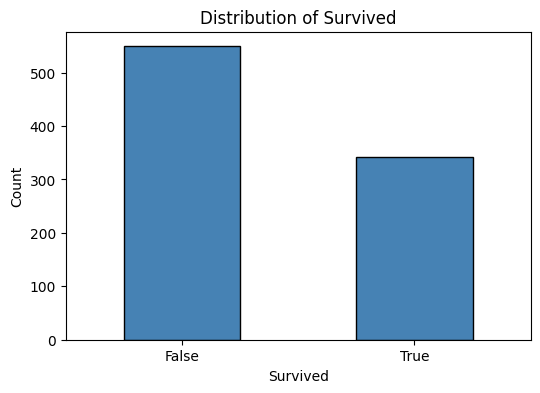

In [35]:
survived_s = titanic_df['Survived'].apply(lambda x: True if x == 1 else False)
plot_categorical_column(survived_s.to_frame(), 'Survived')

Widzimy żę większośc pasażerów Titanica nie przeżyła.

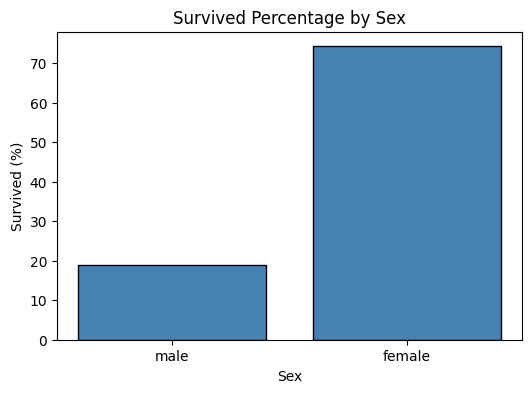

In [36]:
male_survived_percentage = titanic_df.loc[titanic_df['Sex'] == 'male', 'Survived'].mean() * 100
female_survived_percentage = titanic_df.loc[titanic_df['Sex'] == 'female', 'Survived'].mean() * 100

sex = ['male', 'female']
survived_rate = [male_survived_percentage, female_survived_percentage]

plt.figure(figsize=(6, 4))
plt.bar(sex, survived_rate, color='steelblue', edgecolor='black')
plt.title('Survived Percentage by Sex')
plt.xlabel('Sex')
plt.ylabel('Survived (%)')
plt.show()


Z powyższego wykresu widać żę ponad 70 % kobiet przeżyło katastorfę. Jest to o wiele więcej niż mężczyzn, gdzie wskażnik przeżycia wynosi miniej niż 20 %.

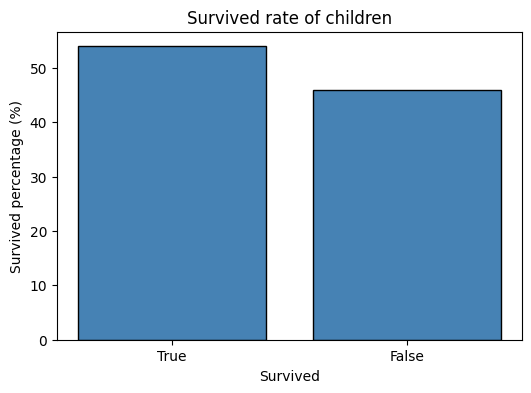

In [56]:
def fix_row(x):
    x['Survived'] = (x['Survived'] == 1)
    return x

children_df = titanic_df.loc[titanic_df['WasChild'] == 1].apply(fix_row, axis=1)
children_survived_percentage = children_df['Survived'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
plt.bar(children_survived_percentage.index.astype(str), children_survived_percentage.values, color='steelblue', edgecolor='black')
plt.title('Survived rate of children')
plt.xlabel('Survived')
plt.ylabel('Survived percentage (%)')
plt.show()


Dzieci uratowane stanowią minimalnie większą ilośc niż tę które zgineły.
Na tej podstwie nie możemy jednoznacznie stwierdzić iż dzieci były ratowane w pierwszej kolejności

### Pclass

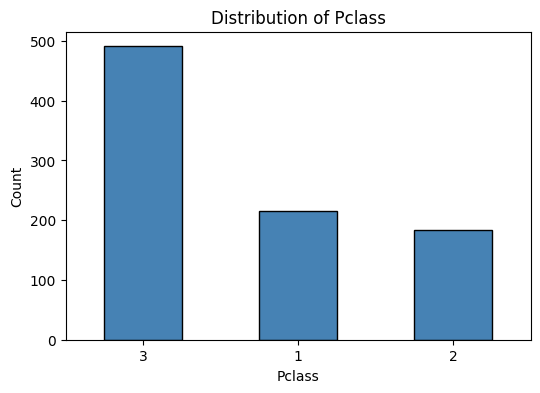

In [18]:

plot_categorical_column(titanic_df, 'Pclass')

Plotbar wizualizujący pasażerów w podziale na klasy podróży. Najwięcej pasażerów miała klasa nr 3 a najmniej 2.

### Sex

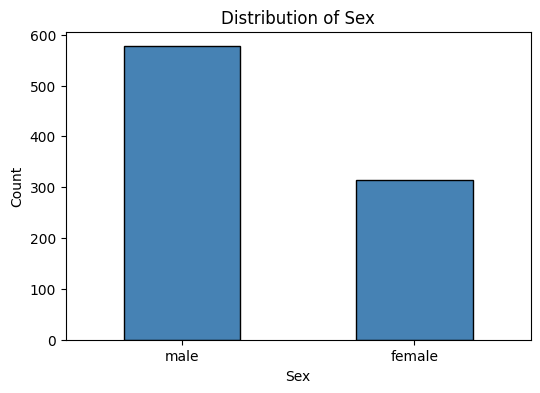

In [19]:
plot_categorical_column(titanic_df, 'Sex')

### Age

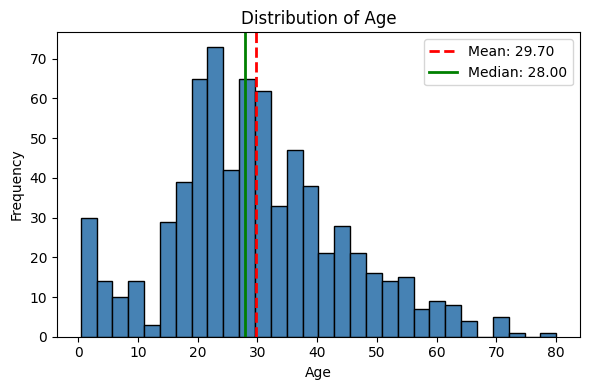

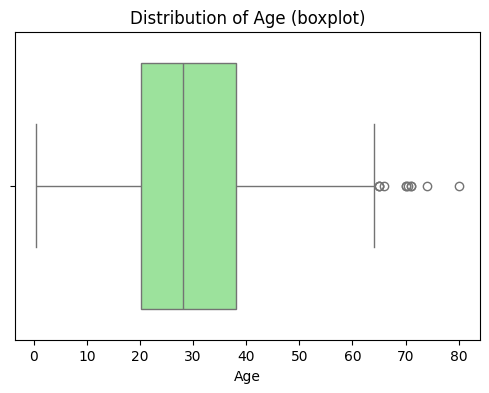

In [20]:
plot_numeric_histogram(titanic_df, 'Age')
boxplot(titanic_df, 'Age')

Histogram oraz boxplot danych dotyczących wieku na statku.
Jest to rozkład w przybliżeniu normalny.

Występują outlinery. Dane te nie są błędne po prostu na statku byli ludzie znacznie starsi od reszty





### Fare

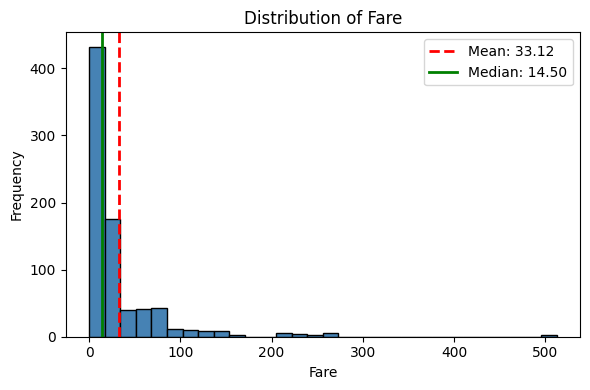

In [21]:
plot_numeric_histogram(titanic_df, 'Fare')


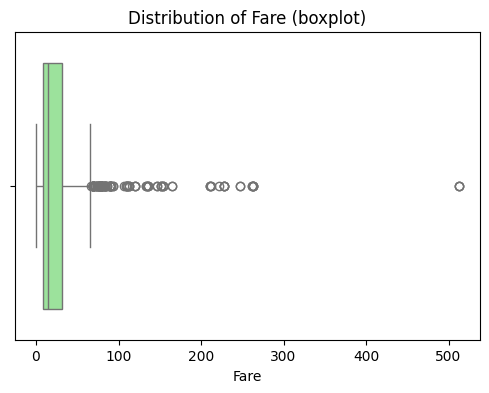

In [22]:
boxplot(titanic_df, 'Fare')

Histogram oraz boxplot danych dotyczących opłąt za bilet na statku.
Jest to rozkład asymetrycznie prawy

Występują outlinery. Dane te nie są błedy. Na statku wsytępował duży rorzut w cenach za przewóz, zależało to od dostępnych luksów w kabinie. Outlinery góry reprezentują pasażerów, którzy wykupili te najdroższe.

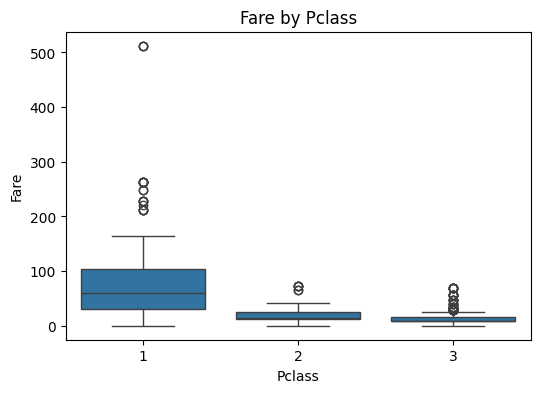

In [23]:
boxplot_with_categorical(titanic_df, 'Fare', 'Pclass')

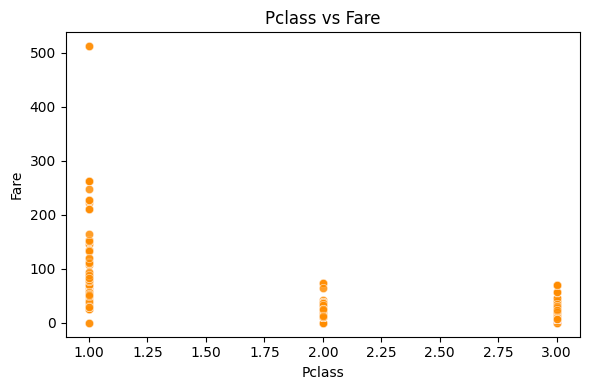

In [24]:
scatterplot(titanic_df, 'Pclass', 'Fare',)

Rozkład opłat za przewóz w stsounku do klasy podróży. Najdorższe były bilety w klasie 1, potem 2 i 3. Wyrażna różnica jest pomiędzy kalsa 1 a 2 i 3. Ceny klasy 2 i 3 są to siębie podobne, lecz kolejność jest zachowana pod kątem średniej

## Uzupełnianie brakujących wartości

`CABIN` uzupełniam przypisując wartościom Na wartośc `Unkown`. Nie udało mi się dokładniej odwożyć tej zmiennej. Roizważałem odwtowrzenie numeru kabinu na podstawie nr. kabiny, lecz ne znalazłem powiązania=

In [25]:
titanic_df.loc[titanic_df['Cabin'].isna(),'Cabin'] = 'Unkown'
titanic_df.loc[titanic_df['Cabin'] == 'Unkown'].head(1)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,WithFamily,WasChild
PassengerId,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,Unkown,S,1,0


### Age

`Age ` postanaiwm uzupełnić średnią, gdyż histogram wieku to rozkład normalny

In [26]:
age_mean = titanic_df['Age'].mean().round(2)
titanic_df.loc[titanic_df['Age'].isna(),'Age'] = age_mean

### Fare

Fare możemy uzupełnić na dwa sposoby:
1. Kierując sie faktem że zachowuje on rozkład prawy asymetryczny
2. Na podstawie rozkładu kosztów biletów w zależności od klasy podróży.

Wybrałęm sposób nr. 2 . Nie ma w nim ryzuku przypisania niskin cech biletów do klasy nr 1, co buży wyżej opisana przeze mnie zależność.


In [27]:
for pclass in [1, 2, 3]:
    missing_mask = (
        (titanic_df["Fare"].isna())
        & (titanic_df["Pclass"] == pclass)

    )

    fare_distribution = get_column_distribution(
        titanic_df.loc[titanic_df["Pclass"] == pclass],
        'Fare'

    )

    titanic_df.loc[missing_mask, "Fare"] =np.random.choice(
        fare_distribution.index.to_numpy(),
        size=missing_mask.sum(),
        p=fare_distribution,
    )



### Embarked

Ze względu na mała ilość brakuących danych o tej cesze, postanawiam uzpełnić ją na podstawie jej rozkładu

In [28]:
embarked_distribution = get_column_distribution(titanic_df, 'Embarked')
is_embarked_na = titanic_df['Embarked'].isna()
titanic_df.loc[is_embarked_na, 'Embarked'] = np.random.choice(embarked_distribution.index.to_numpy(),size= titanic_df[is_embarked_na].shape[0], p = embarked_distribution)

In [29]:
get_percentage_missing(titanic_df, axis=0)

,0


## Usunięcie nieistotnych kolumn

Analizują, które cechy miały wpływ na przeżycie pasażerów za nieistotne uważam
1. `Name` - imie jest mało istotne w kontekście szans na przeżycie
2. `Ticket` - to samo co powyżej

In [30]:
titanic_df = titanic_df.drop(columns=['Name'])
titanic_df = titanic_df.drop(columns=['Ticket'])
titanic_df.dtypes

,0
Survived,int64
Pclass,int64
Sex,object
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Cabin,object
Embarked,object
WithFamily,int64


## Enkodowanie danych kategorialnych

### Sex binary encoding

In [31]:
titanic_df = pd.get_dummies(titanic_df, columns=['Sex'], prefix='Sex', dtype=np.int32)
titanic_df.head(n=1)

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Embarked,WithFamily,WasChild,Sex_female,Sex_male
PassengerId,,,,,,,,,,,,
1,0,3,22.0,1,0,7.25,Unkown,S,1,0,0,1


### Embarked hot one encoding

In [32]:
titanic_df = pd.get_dummies(data=titanic_df, prefix='Embarked', columns=['Embarked'], dtype=np.int32) # pass in dataframe and columns to one-hot code
titanic_df.head(n=1)

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,WithFamily,WasChild,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,,,
1,0,3,22.0,1,0,7.25,Unkown,1,0,0,1,0,0,1
